## t-sne

✅ Scikit-learn version: 1.7.0
✅ All imports successful!
✅ Configuration set!
🚀 Starting t-SNE Visualization for Real vs Synthetic Email Phishing Data

📖 STEP 1: LOADING DATA
----------------------------------------
📁 Loading real data from: ../raw/five_email_phishing_train.csv.gz
   ✅ Loaded 2000 real samples
   📊 Columns: ['subject', 'body', 'label', 'source']
   📈 Label distribution: {1: 1000, 0: 1000}
📁 Loading synthetic data from: ../data/synthetic/five_email_phishing_synthetic.csv.gz
   ✅ Loaded 2000 synthetic samples
   📊 Columns: ['subject', 'body', 'label', 'source', 'sample_id', 'generation_timestamp', 'source_file', 'file_index']
   📈 Label distribution: {1: 1000, 0: 1000}

🔧 STEP 2: PREPROCESSING DATA
----------------------------------------
🔄 Combining text features...
   ✅ Combined text features for 2000 samples
🔄 Combining text features...
   ✅ Combined text features for 2000 samples
   ✅ Combined dataset: 4000 samples

🔍 STEP 3: FEATURE EXTRACTION
-----------------------

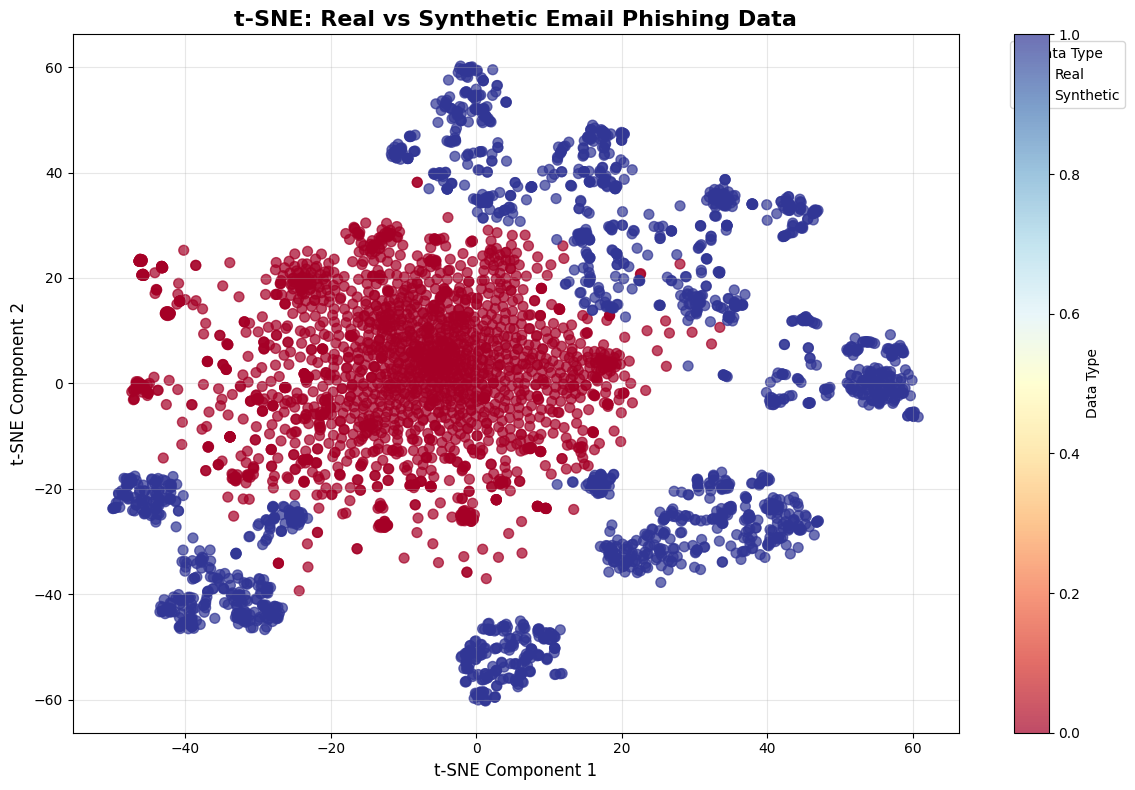

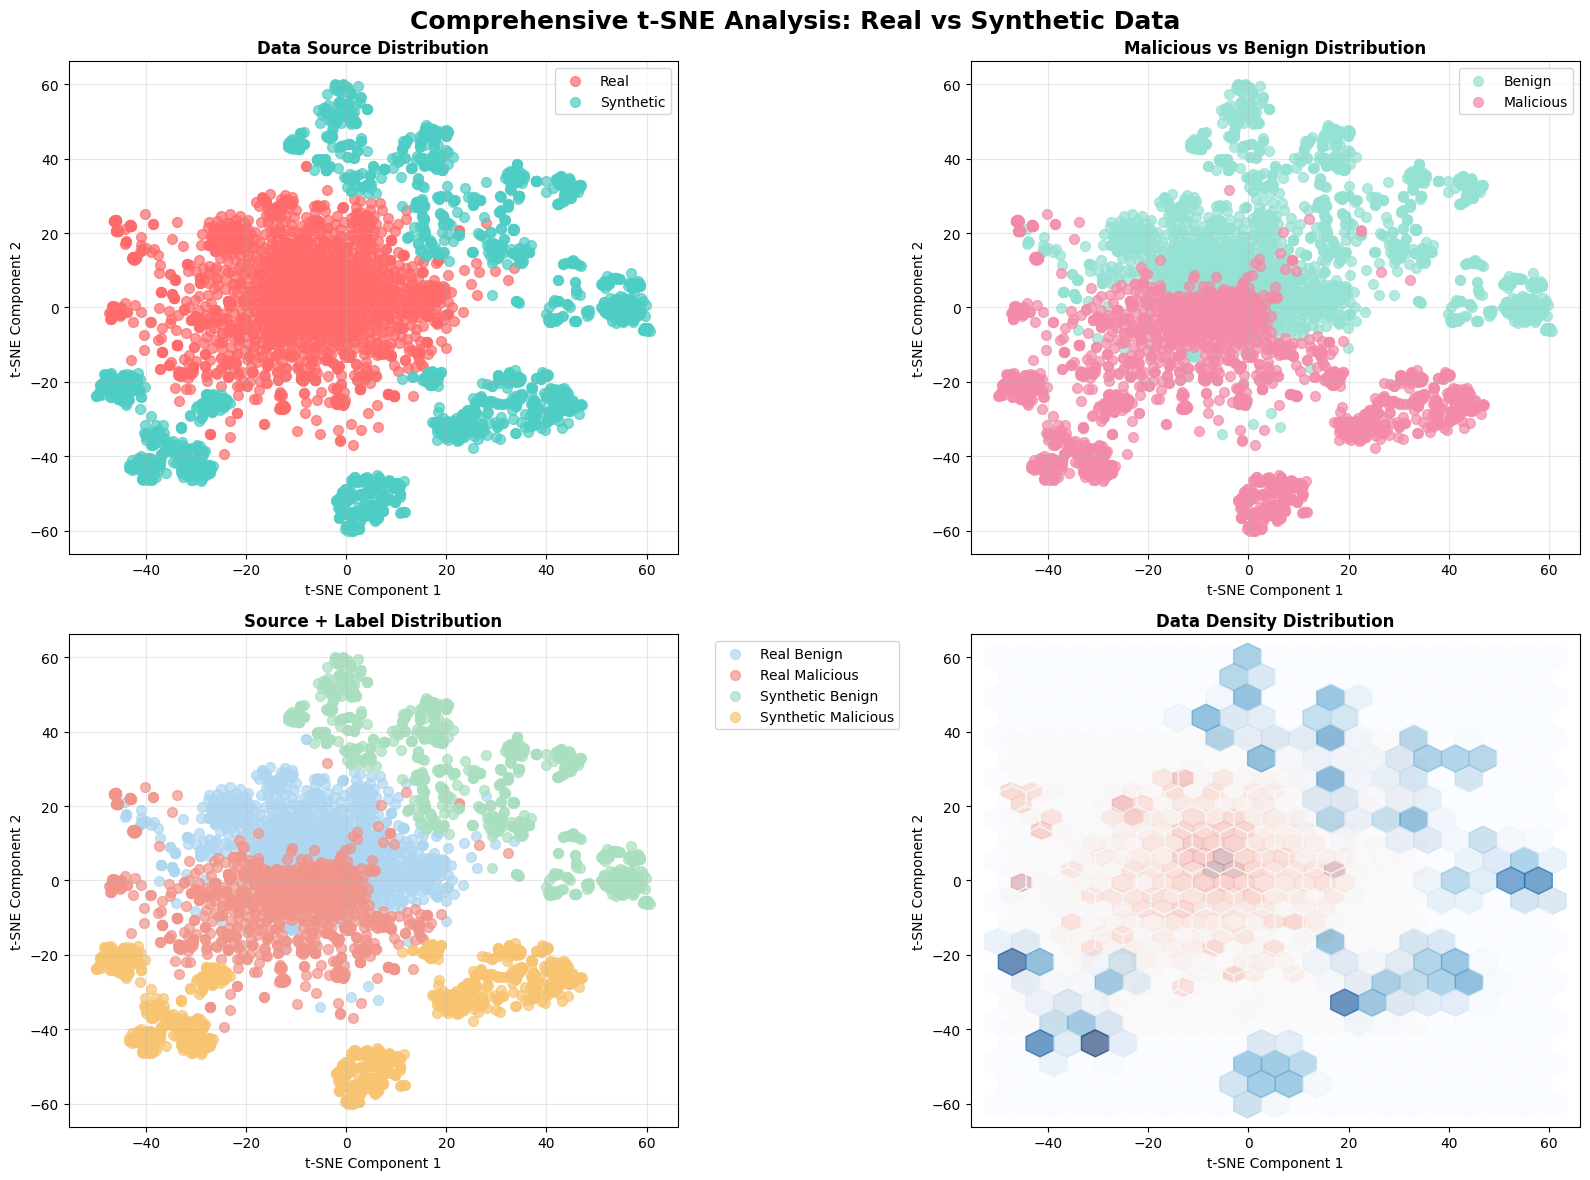

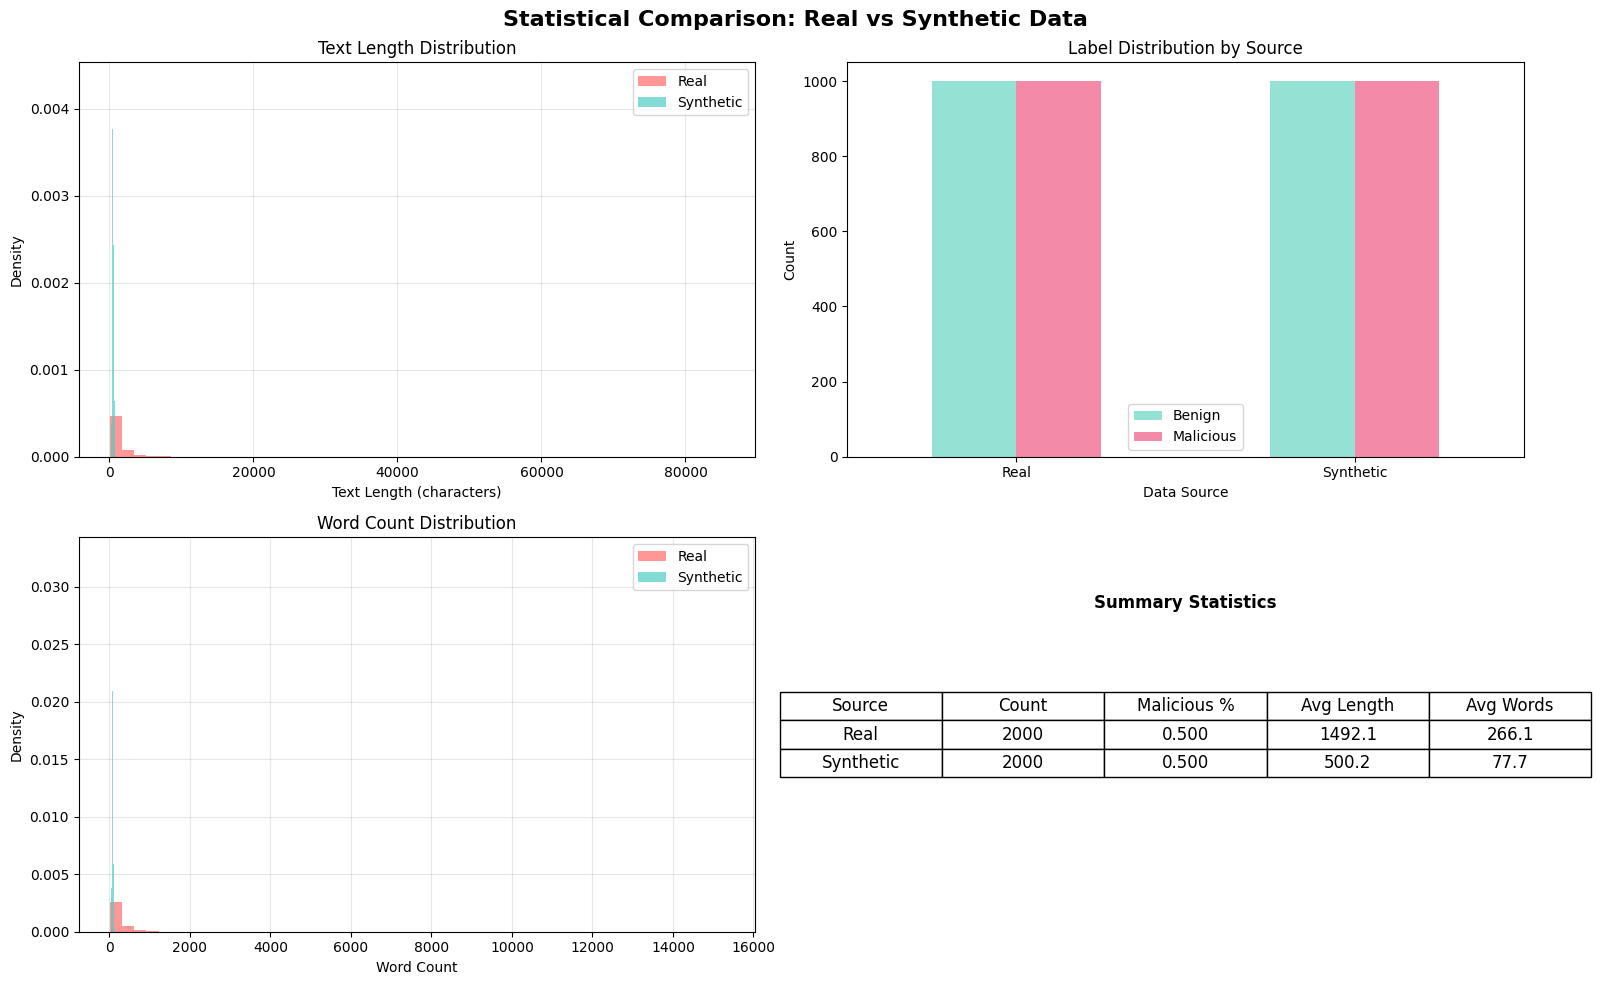


📋 STEP 6: SUMMARY ANALYSIS
----------------------------------------
📊 SUMMARY METRICS:
   • Real samples: 2000
   • Synthetic samples: 2000
   • TF-IDF features: 5000
   • Avg distance synthetic→real: 13.3815
   • Min distance synthetic→real: 1.1331
   • Max distance synthetic→real: 31.9631

📈 LABEL DISTRIBUTION:
   • Real: 50.0% malicious
   • Synthetic: 50.0% malicious

🎉 t-SNE visualization completed successfully!


In [6]:
#!/usr/bin/env python3
"""
t-SNE Visualization for Real vs Synthetic Email Phishing Data
===========================================================

This notebook visualizes the relationship between real-world and synthetic
email phishing data using t-SNE dimensionality reduction.

Dataset Schema: ['subject', 'body', 'label', 'source']
- subject: Email subject line
- body: Email body content
- label: 0 (benign) or 1 (malicious)
- source: Data source identifier
"""

# ============================================================================
# IMPORTS AND SETUP
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Text processing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

# Dimensionality reduction
from sklearn.manifold import TSNE

# Additional text processing
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Download required NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('punkt')
    nltk.download('stopwords')

# Set style for better compatibility
plt.style.use('default')  # Use default style for better compatibility
sns.set_palette("husl")

# Check sklearn version for compatibility
from sklearn import __version__ as sklearn_version
print(f"✅ Scikit-learn version: {sklearn_version}")

print("✅ All imports successful!")

# ============================================================================
# CONFIGURATION
# ============================================================================

# File paths
TRAIN_FILE = "../raw/five_email_phishing_train.csv.gz"
SYNTHETIC_FILE = "../data/synthetic/five_email_phishing_synthetic.csv.gz"

# Alternative paths (adjust as needed)
ALT_TRAIN_FILE = "../raw/five_email_phishing.csv.gz"
ALT_SYNTHETIC_FILE = "../data/scaled-validated/Social_Engineering/phishing_scale.json"

# t-SNE parameters
TSNE_PERPLEXITY = 30
TSNE_MAX_ITER = 1000
TSNE_RANDOM_STATE = 42

# Sampling parameters (for performance)
MAX_SAMPLES_PER_TYPE = 2000  # Limit samples for faster computation
SAMPLE_RANDOM_STATE = 42

# Text processing parameters
MAX_FEATURES = 5000  # TF-IDF features
MIN_DF = 2  # Minimum document frequency
MAX_DF = 0.95  # Maximum document frequency

print("✅ Configuration set!")

# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_real_data(file_path):
    """Load real email phishing data from CSV."""
    try:
        print(f"📁 Loading real data from: {file_path}")
        
        if str(file_path).endswith('.gz'):
            with gzip.open(file_path, 'rt', encoding='utf-8') as f:
                df = pd.read_csv(f)
        else:
            df = pd.read_csv(file_path)
        
        print(f"   ✅ Loaded {len(df)} real samples")
        print(f"   📊 Columns: {list(df.columns)}")
        print(f"   📈 Label distribution: {df['label'].value_counts().to_dict()}")
        
        return df
        
    except FileNotFoundError:
        print(f"   ❌ File not found: {file_path}")
        return None
    except Exception as e:
        print(f"   ❌ Error loading real data: {e}")
        return None

def load_synthetic_data(file_path):
    """Load synthetic data from CSV or JSON."""
    try:
        print(f"📁 Loading synthetic data from: {file_path}")
        
        if str(file_path).endswith('.json'):
            # Load from JSON (CyberData format)
            import json
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            samples = data.get('samples', [])
            df = pd.DataFrame(samples)
            
        elif str(file_path).endswith('.gz'):
            # Load from compressed CSV
            with gzip.open(file_path, 'rt', encoding='utf-8') as f:
                df = pd.read_csv(f)
        else:
            # Load from regular CSV
            df = pd.read_csv(file_path)
        
        print(f"   ✅ Loaded {len(df)} synthetic samples")
        print(f"   📊 Columns: {list(df.columns)}")
        
        if 'label' in df.columns:
            print(f"   📈 Label distribution: {df['label'].value_counts().to_dict()}")
        
        return df
        
    except FileNotFoundError:
        print(f"   ❌ File not found: {file_path}")
        return None
    except Exception as e:
        print(f"   ❌ Error loading synthetic data: {e}")
        return None

# ============================================================================
# TEXT PREPROCESSING
# ============================================================================

def clean_text(text):
    """Clean and preprocess text data."""
    if pd.isna(text) or text == '':
        return ''
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)
    
    # Remove URLs
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remove special characters but keep spaces
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

def combine_text_features(df):
    """Combine subject and body into a single text feature."""
    print("🔄 Combining text features...")
    
    # Clean individual fields
    df['subject_clean'] = df['subject'].apply(clean_text)
    df['body_clean'] = df['body'].apply(clean_text)
    
    # Combine subject and body with weight (subject is more important)
    df['combined_text'] = (df['subject_clean'] + ' ' + 
                          df['subject_clean'] + ' ' +  # Give subject more weight
                          df['body_clean'])
    
    # Remove empty texts
    df = df[df['combined_text'].str.len() > 0].copy()
    
    print(f"   ✅ Combined text features for {len(df)} samples")
    return df

# ============================================================================
# FEATURE EXTRACTION
# ============================================================================

def extract_tfidf_features(texts, vectorizer=None, fit=True):
    """Extract TF-IDF features from text data."""
    print("🔄 Extracting TF-IDF features...")
    
    if vectorizer is None:
        vectorizer = TfidfVectorizer(
            max_features=MAX_FEATURES,
            min_df=MIN_DF,
            max_df=MAX_DF,
            stop_words='english',
            ngram_range=(1, 2),  # Unigrams and bigrams
            lowercase=True,
            strip_accents='unicode'
        )
    
    if fit:
        features = vectorizer.fit_transform(texts)
        print(f"   ✅ Extracted {features.shape[1]} TF-IDF features from {features.shape[0]} texts")
    else:
        features = vectorizer.transform(texts)
        print(f"   ✅ Transformed {features.shape[0]} texts using existing vectorizer")
    
    return features, vectorizer

# ============================================================================
# SAMPLING FOR PERFORMANCE
# ============================================================================

def stratified_sample(df, max_samples=MAX_SAMPLES_PER_TYPE, random_state=SAMPLE_RANDOM_STATE):
    """Perform stratified sampling to reduce dataset size for faster computation."""
    if len(df) <= max_samples:
        return df
    
    print(f"🎲 Sampling {max_samples} samples from {len(df)} for performance...")
    
    # Sample by label if available
    if 'label' in df.columns:
        sampled_dfs = []
        for label in df['label'].unique():
            label_df = df[df['label'] == label]
            n_samples = min(len(label_df), max_samples // len(df['label'].unique()))
            sampled_df = label_df.sample(n=n_samples, random_state=random_state)
            sampled_dfs.append(sampled_df)
        
        result = pd.concat(sampled_dfs, ignore_index=True)
    else:
        result = df.sample(n=max_samples, random_state=random_state)
    
    print(f"   ✅ Sampled {len(result)} samples")
    return result

# ============================================================================
# t-SNE COMPUTATION
# ============================================================================

def compute_tsne(features, perplexity=TSNE_PERPLEXITY, max_iter=TSNE_MAX_ITER, random_state=TSNE_RANDOM_STATE):
    """Compute t-SNE embedding."""
    print(f"🧮 Computing t-SNE with perplexity={perplexity}, max_iter={max_iter}...")
    
    # Initialize t-SNE
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        max_iter=max_iter,
        random_state=random_state,
        verbose=1,
        init='random',  # Use random initialization for better compatibility
        learning_rate='auto'  # Use auto learning rate for better results
    )
    
    # Convert sparse matrix to dense if needed
    if hasattr(features, 'toarray'):
        features_dense = features.toarray()
    else:
        features_dense = features
    
    # Compute embedding
    embedding = tsne.fit_transform(features_dense)
    
    print(f"   ✅ t-SNE embedding computed: {embedding.shape}")
    return embedding

# ============================================================================
# VISUALIZATION FUNCTIONS
# ============================================================================

def plot_tsne_basic(embedding, labels, data_type, title="t-SNE Visualization"):
    """Create basic t-SNE visualization."""
    plt.figure(figsize=(12, 8))
    
    # Create scatter plot
    scatter = plt.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=labels, 
        cmap='RdYlBu', 
        alpha=0.7,
        s=50
    )
    
    plt.colorbar(scatter, label='Data Type')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add legend
    unique_labels = np.unique(labels)
    for i, label in enumerate(unique_labels):
        plt.scatter([], [], c=plt.cm.RdYlBu(i/len(unique_labels)), 
                   label=data_type[int(label)], s=100)
    plt.legend(title='Data Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

def plot_tsne_advanced(embedding, df_combined, title="Advanced t-SNE Visualization"):
    """Create advanced t-SNE visualization with multiple subplots."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(title, fontsize=18, fontweight='bold')
    
    # Plot 1: Data Source (Real vs Synthetic)
    ax1 = axes[0, 0]
    colors = ['#FF6B6B', '#4ECDC4']  # Red for real, teal for synthetic
    for i, source in enumerate(['Real', 'Synthetic']):
        mask = df_combined['data_source'] == source
        ax1.scatter(
            embedding[mask, 0], 
            embedding[mask, 1], 
            c=colors[i], 
            label=source, 
            alpha=0.7, 
            s=50
        )
    ax1.set_title('Data Source Distribution', fontweight='bold')
    ax1.set_xlabel('t-SNE Component 1')
    ax1.set_ylabel('t-SNE Component 2')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Label Distribution (Malicious vs Benign)
    ax2 = axes[0, 1]
    label_colors = ['#95E1D3', '#F38BA8']  # Green for benign, pink for malicious
    for i, label in enumerate([0, 1]):
        mask = df_combined['label'] == label
        label_name = 'Benign' if label == 0 else 'Malicious'
        ax2.scatter(
            embedding[mask, 0], 
            embedding[mask, 1], 
            c=label_colors[i], 
            label=label_name, 
            alpha=0.7, 
            s=50
        )
    ax2.set_title('Malicious vs Benign Distribution', fontweight='bold')
    ax2.set_xlabel('t-SNE Component 1')
    ax2.set_ylabel('t-SNE Component 2')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Combined Source + Label
    ax3 = axes[1, 0]
    source_label_colors = {
        ('Real', 0): '#AED6F1',      # Light blue
        ('Real', 1): '#F1948A',      # Light red
        ('Synthetic', 0): '#A9DFBF', # Light green  
        ('Synthetic', 1): '#F8C471'  # Light orange
    }
    
    for (source, label), color in source_label_colors.items():
        mask = (df_combined['data_source'] == source) & (df_combined['label'] == label)
        if mask.sum() > 0:
            label_name = f"{source} {'Malicious' if label == 1 else 'Benign'}"
            ax3.scatter(
                embedding[mask, 0], 
                embedding[mask, 1], 
                c=color, 
                label=label_name, 
                alpha=0.7, 
                s=50
            )
    
    ax3.set_title('Source + Label Distribution', fontweight='bold')
    ax3.set_xlabel('t-SNE Component 1')
    ax3.set_ylabel('t-SNE Component 2')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Density plot
    ax4 = axes[1, 1]
    real_mask = df_combined['data_source'] == 'Real'
    synthetic_mask = df_combined['data_source'] == 'Synthetic'
    
    # Create density plots
    ax4.hexbin(embedding[real_mask, 0], embedding[real_mask, 1], 
              gridsize=20, alpha=0.6, cmap='Reds', label='Real')
    ax4.hexbin(embedding[synthetic_mask, 0], embedding[synthetic_mask, 1], 
              gridsize=20, alpha=0.6, cmap='Blues', label='Synthetic')
    
    ax4.set_title('Data Density Distribution', fontweight='bold')
    ax4.set_xlabel('t-SNE Component 1')
    ax4.set_ylabel('t-SNE Component 2')
    
    plt.tight_layout()
    plt.show()

def plot_statistics_comparison(df_combined):
    """Plot statistical comparisons between real and synthetic data."""
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Statistical Comparison: Real vs Synthetic Data', fontsize=16, fontweight='bold')
    
    # Text length distribution
    ax1 = axes[0, 0]
    df_combined['text_length'] = df_combined['combined_text'].str.len()
    
    real_lengths = df_combined[df_combined['data_source'] == 'Real']['text_length']
    synthetic_lengths = df_combined[df_combined['data_source'] == 'Synthetic']['text_length']
    
    ax1.hist(real_lengths, bins=50, alpha=0.7, label='Real', color='#FF6B6B', density=True)
    ax1.hist(synthetic_lengths, bins=50, alpha=0.7, label='Synthetic', color='#4ECDC4', density=True)
    ax1.set_title('Text Length Distribution')
    ax1.set_xlabel('Text Length (characters)')
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Label distribution by source
    ax2 = axes[0, 1]
    label_counts = df_combined.groupby(['data_source', 'label']).size().unstack(fill_value=0)
    label_counts.plot(kind='bar', ax=ax2, color=['#95E1D3', '#F38BA8'])
    ax2.set_title('Label Distribution by Source')
    ax2.set_xlabel('Data Source')
    ax2.set_ylabel('Count')
    ax2.legend(['Benign', 'Malicious'])
    ax2.tick_params(axis='x', rotation=0)
    
    # Word count distribution
    ax3 = axes[1, 0]
    df_combined['word_count'] = df_combined['combined_text'].str.split().str.len()
    
    real_words = df_combined[df_combined['data_source'] == 'Real']['word_count']
    synthetic_words = df_combined[df_combined['data_source'] == 'Synthetic']['word_count']
    
    ax3.hist(real_words, bins=50, alpha=0.7, label='Real', color='#FF6B6B', density=True)
    ax3.hist(synthetic_words, bins=50, alpha=0.7, label='Synthetic', color='#4ECDC4', density=True)
    ax3.set_title('Word Count Distribution')
    ax3.set_xlabel('Word Count')
    ax3.set_ylabel('Density')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Summary statistics table
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    stats_data = []
    for source in ['Real', 'Synthetic']:
        data = df_combined[df_combined['data_source'] == source]
        stats_data.append([
            source,
            len(data),
            f"{(data['label'] == 1).mean():.3f}",
            f"{data['text_length'].mean():.1f}",
            f"{data['word_count'].mean():.1f}"
        ])
    
    table = ax4.table(
        cellText=stats_data,
        colLabels=['Source', 'Count', 'Malicious %', 'Avg Length', 'Avg Words'],
        cellLoc='center',
        loc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    table.scale(1.2, 1.5)
    ax4.set_title('Summary Statistics', y=0.8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function."""
    print("🚀 Starting t-SNE Visualization for Real vs Synthetic Email Phishing Data")
    print("=" * 80)
    
    # ========================================================================
    # 1. LOAD DATA
    # ========================================================================
    print("\n📖 STEP 1: LOADING DATA")
    print("-" * 40)
    
    # Try to load real data
    real_df = load_real_data(TRAIN_FILE)
    if real_df is None:
        print("   🔄 Trying alternative path...")
        real_df = load_real_data(ALT_TRAIN_FILE)
    
    if real_df is None:
        print("   ❌ Could not load real data. Please check file paths.")
        return
    
    # Try to load synthetic data
    synthetic_df = load_synthetic_data(SYNTHETIC_FILE)
    if synthetic_df is None:
        print("   🔄 Trying alternative path...")
        synthetic_df = load_synthetic_data(ALT_SYNTHETIC_FILE)
    
    if synthetic_df is None:
        print("   ❌ Could not load synthetic data. Please check file paths.")
        return
    
    # ========================================================================
    # 2. PREPROCESS DATA
    # ========================================================================
    print("\n🔧 STEP 2: PREPROCESSING DATA")
    print("-" * 40)
    
    # Add data source labels
    real_df['data_source'] = 'Real'
    synthetic_df['data_source'] = 'Synthetic'
    
    # Ensure consistent schema
    required_cols = ['subject', 'body', 'label']
    for col in required_cols:
        if col not in real_df.columns:
            print(f"   ⚠️  Missing column '{col}' in real data")
            real_df[col] = ''
        if col not in synthetic_df.columns:
            print(f"   ⚠️  Missing column '{col}' in synthetic data")
            synthetic_df[col] = ''
    
    # Clean and combine text features
    real_df = combine_text_features(real_df)
    synthetic_df = combine_text_features(synthetic_df)
    
    # Sample data for performance
    real_df_sampled = stratified_sample(real_df, MAX_SAMPLES_PER_TYPE)
    synthetic_df_sampled = stratified_sample(synthetic_df, MAX_SAMPLES_PER_TYPE)
    
    # Combine datasets
    df_combined = pd.concat([real_df_sampled, synthetic_df_sampled], ignore_index=True)
    print(f"   ✅ Combined dataset: {len(df_combined)} samples")
    
    # ========================================================================
    # 3. EXTRACT FEATURES
    # ========================================================================
    print("\n🔍 STEP 3: FEATURE EXTRACTION")
    print("-" * 40)
    
    # Extract TF-IDF features
    features, vectorizer = extract_tfidf_features(df_combined['combined_text'])
    
    # ========================================================================
    # 4. COMPUTE t-SNE
    # ========================================================================
    print("\n🧮 STEP 4: COMPUTING t-SNE")
    print("-" * 40)
    
    embedding = compute_tsne(features)
    
    # ========================================================================
    # 5. VISUALIZE RESULTS
    # ========================================================================
    print("\n📊 STEP 5: CREATING VISUALIZATIONS")
    print("-" * 40)
    
    # Create basic visualization
    data_labels = df_combined['data_source'].map({'Real': 0, 'Synthetic': 1}).values
    plot_tsne_basic(
        embedding, 
        data_labels, 
        {0: 'Real', 1: 'Synthetic'},
        "t-SNE: Real vs Synthetic Email Phishing Data"
    )
    
    # Create advanced visualization
    plot_tsne_advanced(
        embedding, 
        df_combined,
        "Comprehensive t-SNE Analysis: Real vs Synthetic Data"
    )
    
    # Create statistical comparison
    plot_statistics_comparison(df_combined)
    
    # ========================================================================
    # 6. SUMMARY ANALYSIS
    # ========================================================================
    print("\n📋 STEP 6: SUMMARY ANALYSIS")
    print("-" * 40)
    
    # Calculate overlap metrics
    from scipy.spatial.distance import cdist
    
    real_mask = df_combined['data_source'] == 'Real'
    synthetic_mask = df_combined['data_source'] == 'Synthetic'
    
    real_embedding = embedding[real_mask]
    synthetic_embedding = embedding[synthetic_mask]
    
    # Calculate nearest neighbor distances
    distances = cdist(synthetic_embedding, real_embedding)
    min_distances = np.min(distances, axis=1)
    
    print(f"📊 SUMMARY METRICS:")
    print(f"   • Real samples: {real_mask.sum()}")
    print(f"   • Synthetic samples: {synthetic_mask.sum()}")
    print(f"   • TF-IDF features: {features.shape[1]}")
    print(f"   • Avg distance synthetic→real: {np.mean(min_distances):.4f}")
    print(f"   • Min distance synthetic→real: {np.min(min_distances):.4f}")
    print(f"   • Max distance synthetic→real: {np.max(min_distances):.4f}")
    
    # Label distribution analysis
    print(f"\n📈 LABEL DISTRIBUTION:")
    for source in ['Real', 'Synthetic']:
        source_data = df_combined[df_combined['data_source'] == source]
        malicious_pct = (source_data['label'] == 1).mean() * 100
        print(f"   • {source}: {malicious_pct:.1f}% malicious")
    
    print("\n🎉 t-SNE visualization completed successfully!")
    print("=" * 80)

# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

if __name__ == "__main__":
    main()

## Metric

In [8]:
#!/usr/bin/env python3
"""
Dataset Coherence Evaluation Metrics
====================================

Comprehensive metrics to evaluate the coherence and similarity between 
real and synthetic datasets with multiple labels (malicious/benign).

This module provides various distance metrics, distribution comparisons,
and statistical tests to assess synthetic data quality.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class DatasetCoherenceEvaluator:
    """
    Comprehensive evaluation of coherence between real and synthetic datasets.
    """
    
    def __init__(self, features_real, features_synthetic, labels_real, labels_synthetic):
        """
        Initialize evaluator with feature matrices and labels.
        
        Args:
            features_real: Feature matrix for real data (n_samples, n_features)
            features_synthetic: Feature matrix for synthetic data (n_samples, n_features)
            labels_real: Labels for real data (0=benign, 1=malicious)
            labels_synthetic: Labels for synthetic data (0=benign, 1=malicious)
        """
        self.features_real = np.array(features_real)
        self.features_synthetic = np.array(features_synthetic)
        self.labels_real = np.array(labels_real)
        self.labels_synthetic = np.array(labels_synthetic)
        
        # Standardize features for distance calculations
        scaler = StandardScaler()
        all_features = np.vstack([self.features_real, self.features_synthetic])
        scaler.fit(all_features)
        
        self.features_real_scaled = scaler.transform(self.features_real)
        self.features_synthetic_scaled = scaler.transform(self.features_synthetic)
        
        print(f"✅ Initialized evaluator:")
        print(f"   Real data: {self.features_real.shape[0]} samples, {self.features_real.shape[1]} features")
        print(f"   Synthetic data: {self.features_synthetic.shape[0]} samples, {self.features_synthetic.shape[1]} features")
        print(f"   Real labels: {np.bincount(self.labels_real)} [benign, malicious]")
        print(f"   Synthetic labels: {np.bincount(self.labels_synthetic)} [benign, malicious]")
    
    def centroid_distance_metrics(self):
        """
        Calculate centroid-based distance metrics between real and synthetic data.
        """
        print("\n📏 Computing Centroid Distance Metrics...")
        
        results = {}
        
        # Overall centroids
        centroid_real = np.mean(self.features_real_scaled, axis=0)
        centroid_synthetic = np.mean(self.features_synthetic_scaled, axis=0)
        
        # Label-specific centroids
        centroid_real_benign = np.mean(self.features_real_scaled[self.labels_real == 0], axis=0)
        centroid_real_malicious = np.mean(self.features_real_scaled[self.labels_real == 1], axis=0)
        centroid_synthetic_benign = np.mean(self.features_synthetic_scaled[self.labels_synthetic == 0], axis=0)
        centroid_synthetic_malicious = np.mean(self.features_synthetic_scaled[self.labels_synthetic == 1], axis=0)
        
        # Distance calculations
        results['overall_centroid_distance'] = np.linalg.norm(centroid_real - centroid_synthetic)
        results['benign_centroid_distance'] = np.linalg.norm(centroid_real_benign - centroid_synthetic_benign)
        results['malicious_centroid_distance'] = np.linalg.norm(centroid_real_malicious - centroid_synthetic_malicious)
        
        # Cross-label distances (should be larger)
        results['real_inter_label_distance'] = np.linalg.norm(centroid_real_benign - centroid_real_malicious)
        results['synthetic_inter_label_distance'] = np.linalg.norm(centroid_synthetic_benign - centroid_synthetic_malicious)
        
        # Relative coherence metrics
        results['benign_coherence_ratio'] = results['benign_centroid_distance'] / results['real_inter_label_distance']
        results['malicious_coherence_ratio'] = results['malicious_centroid_distance'] / results['real_inter_label_distance']
        
        print(f"   Overall centroid distance: {results['overall_centroid_distance']:.4f}")
        print(f"   Benign centroid distance: {results['benign_centroid_distance']:.4f}")
        print(f"   Malicious centroid distance: {results['malicious_centroid_distance']:.4f}")
        print(f"   Benign coherence ratio: {results['benign_coherence_ratio']:.4f}")
        print(f"   Malicious coherence ratio: {results['malicious_coherence_ratio']:.4f}")
        
        return results
    
    def wasserstein_distance_metrics(self):
        """
        Calculate Wasserstein (Earth Mover's) distance between distributions.
        """
        print("\n🌍 Computing Wasserstein Distance Metrics...")
        
        results = {}
        
        # For each feature dimension, calculate Wasserstein distance
        n_features = min(50, self.features_real_scaled.shape[1])  # Limit for performance
        
        # Overall Wasserstein distances
        wasserstein_overall = []
        wasserstein_benign = []
        wasserstein_malicious = []
        
        for i in range(n_features):
            # Overall
            w_overall = stats.wasserstein_distance(
                self.features_real_scaled[:, i], 
                self.features_synthetic_scaled[:, i]
            )
            wasserstein_overall.append(w_overall)
            
            # Benign samples
            real_benign = self.features_real_scaled[self.labels_real == 0, i]
            synthetic_benign = self.features_synthetic_scaled[self.labels_synthetic == 0, i]
            if len(real_benign) > 0 and len(synthetic_benign) > 0:
                w_benign = stats.wasserstein_distance(real_benign, synthetic_benign)
                wasserstein_benign.append(w_benign)
            
            # Malicious samples
            real_malicious = self.features_real_scaled[self.labels_real == 1, i]
            synthetic_malicious = self.features_synthetic_scaled[self.labels_synthetic == 1, i]
            if len(real_malicious) > 0 and len(synthetic_malicious) > 0:
                w_malicious = stats.wasserstein_distance(real_malicious, synthetic_malicious)
                wasserstein_malicious.append(w_malicious)
        
        results['wasserstein_overall_mean'] = np.mean(wasserstein_overall)
        results['wasserstein_overall_std'] = np.std(wasserstein_overall)
        results['wasserstein_benign_mean'] = np.mean(wasserstein_benign) if wasserstein_benign else np.nan
        results['wasserstein_malicious_mean'] = np.mean(wasserstein_malicious) if wasserstein_malicious else np.nan
        
        print(f"   Overall Wasserstein distance: {results['wasserstein_overall_mean']:.4f} ± {results['wasserstein_overall_std']:.4f}")
        print(f"   Benign Wasserstein distance: {results['wasserstein_benign_mean']:.4f}")
        print(f"   Malicious Wasserstein distance: {results['wasserstein_malicious_mean']:.4f}")
        
        return results
    
    def maximum_mean_discrepancy(self, sigma=1.0):
        """
        Calculate Maximum Mean Discrepancy (MMD) between datasets.
        """
        print("\n🎯 Computing Maximum Mean Discrepancy...")
        
        def rbf_kernel(X, Y, sigma):
            """RBF kernel for MMD calculation."""
            XX = np.sum(X**2, axis=1)[:, None]
            YY = np.sum(Y**2, axis=1)[None, :]
            XY = np.dot(X, Y.T)
            distances = XX + YY - 2*XY
            return np.exp(-distances / (2 * sigma**2))
        
        def mmd_distance(X, Y, sigma):
            """Calculate MMD distance between two datasets."""
            n, m = X.shape[0], Y.shape[0]
            
            K_XX = rbf_kernel(X, X, sigma)
            K_YY = rbf_kernel(Y, Y, sigma)
            K_XY = rbf_kernel(X, Y, sigma)
            
            mmd = (np.sum(K_XX) / (n * n) + 
                   np.sum(K_YY) / (m * m) - 
                   2 * np.sum(K_XY) / (n * m))
            
            return np.sqrt(max(mmd, 0))
        
        results = {}
        
        # Overall MMD
        results['mmd_overall'] = mmd_distance(
            self.features_real_scaled, 
            self.features_synthetic_scaled, 
            sigma
        )
        
        # Label-specific MMD
        real_benign = self.features_real_scaled[self.labels_real == 0]
        synthetic_benign = self.features_synthetic_scaled[self.labels_synthetic == 0]
        if len(real_benign) > 0 and len(synthetic_benign) > 0:
            results['mmd_benign'] = mmd_distance(real_benign, synthetic_benign, sigma)
        
        real_malicious = self.features_real_scaled[self.labels_real == 1]
        synthetic_malicious = self.features_synthetic_scaled[self.labels_synthetic == 1]
        if len(real_malicious) > 0 and len(synthetic_malicious) > 0:
            results['mmd_malicious'] = mmd_distance(real_malicious, synthetic_malicious, sigma)
        
        print(f"   Overall MMD: {results['mmd_overall']:.4f}")
        print(f"   Benign MMD: {results.get('mmd_benign', 'N/A')}")
        print(f"   Malicious MMD: {results.get('mmd_malicious', 'N/A')}")
        
        return results
    
    def nearest_neighbor_metrics(self, k=5):
        """
        Calculate nearest neighbor-based metrics.
        """
        print(f"\n🔍 Computing {k}-Nearest Neighbor Metrics...")
        
        results = {}
        
        # Overall nearest neighbor analysis
        nbrs_real = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(self.features_real_scaled)
        nbrs_synthetic = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(self.features_synthetic_scaled)
        
        # Real to synthetic distances
        distances_real_to_synthetic, _ = nbrs_synthetic.kneighbors(self.features_real_scaled)
        # Synthetic to real distances  
        distances_synthetic_to_real, _ = nbrs_real.kneighbors(self.features_synthetic_scaled)
        
        results['mean_real_to_synthetic_distance'] = np.mean(distances_real_to_synthetic)
        results['mean_synthetic_to_real_distance'] = np.mean(distances_synthetic_to_real)
        
        # Coverage metrics
        # How well does synthetic data cover real data space?
        real_coverage = np.mean(np.min(distances_real_to_synthetic, axis=1))
        synthetic_coverage = np.mean(np.min(distances_synthetic_to_real, axis=1))
        
        results['real_coverage_by_synthetic'] = real_coverage
        results['synthetic_coverage_by_real'] = synthetic_coverage
        
        # Label-specific analysis
        for label_name, label_value in [('benign', 0), ('malicious', 1)]:
            real_label_mask = self.labels_real == label_value
            synthetic_label_mask = self.labels_synthetic == label_value
            
            if np.sum(real_label_mask) > 0 and np.sum(synthetic_label_mask) > 0:
                real_label_data = self.features_real_scaled[real_label_mask]
                synthetic_label_data = self.features_synthetic_scaled[synthetic_label_mask]
                
                nbrs_label = NearestNeighbors(n_neighbors=min(k, len(synthetic_label_data))).fit(synthetic_label_data)
                distances_label, _ = nbrs_label.kneighbors(real_label_data)
                
                results[f'{label_name}_label_distance'] = np.mean(distances_label)
        
        print(f"   Real→Synthetic distance: {results['mean_real_to_synthetic_distance']:.4f}")
        print(f"   Synthetic→Real distance: {results['mean_synthetic_to_real_distance']:.4f}")
        print(f"   Real coverage: {results['real_coverage_by_synthetic']:.4f}")
        print(f"   Synthetic coverage: {results['synthetic_coverage_by_real']:.4f}")
        
        return results
    
    def statistical_tests(self):
        """
        Perform statistical tests to compare distributions.
        """
        print("\n📊 Computing Statistical Tests...")
        
        results = {}
        
        # Two-sample Kolmogorov-Smirnov tests for each feature
        n_features = min(20, self.features_real_scaled.shape[1])  # Limit for performance
        
        ks_statistics = []
        ks_pvalues = []
        
        for i in range(n_features):
            ks_stat, ks_pval = stats.ks_2samp(
                self.features_real_scaled[:, i], 
                self.features_synthetic_scaled[:, i]
            )
            ks_statistics.append(ks_stat)
            ks_pvalues.append(ks_pval)
        
        results['ks_statistic_mean'] = np.mean(ks_statistics)
        results['ks_statistic_max'] = np.max(ks_statistics)
        results['ks_pvalue_mean'] = np.mean(ks_pvalues)
        results['ks_significant_features'] = np.sum(np.array(ks_pvalues) < 0.05)
        
        # Anderson-Darling test for normality
        try:
            # Test if the combined dataset follows similar distribution patterns
            combined_real = np.mean(self.features_real_scaled, axis=1)
            combined_synthetic = np.mean(self.features_synthetic_scaled, axis=1)
            
            ad_stat, ad_critical, ad_significance = stats.anderson_ksamp([combined_real, combined_synthetic])
            results['anderson_darling_statistic'] = ad_stat
            results['anderson_darling_critical'] = ad_critical
        except:
            results['anderson_darling_statistic'] = np.nan
        
        print(f"   KS statistic (mean): {results['ks_statistic_mean']:.4f}")
        print(f"   KS p-value (mean): {results['ks_pvalue_mean']:.4f}")
        print(f"   Significant features: {results['ks_significant_features']}/{n_features}")
        
        return results
    
    def label_distribution_metrics(self):
        """
        Compare label distributions between real and synthetic data.
        """
        print("\n🏷️  Computing Label Distribution Metrics...")
        
        results = {}
        
        # Label proportions
        real_malicious_prop = np.mean(self.labels_real)
        synthetic_malicious_prop = np.mean(self.labels_synthetic)
        
        results['real_malicious_proportion'] = real_malicious_prop
        results['synthetic_malicious_proportion'] = synthetic_malicious_prop
        results['label_proportion_difference'] = abs(real_malicious_prop - synthetic_malicious_prop)
        
        # Chi-square test for label independence
        real_counts = np.bincount(self.labels_real, minlength=2)
        synthetic_counts = np.bincount(self.labels_synthetic, minlength=2)
        
        contingency_table = np.array([real_counts, synthetic_counts])
        chi2_stat, chi2_pval, _, _ = stats.chi2_contingency(contingency_table)
        
        results['chi2_statistic'] = chi2_stat
        results['chi2_pvalue'] = chi2_pval
        results['label_distribution_similar'] = chi2_pval > 0.05
        
        print(f"   Real malicious %: {real_malicious_prop*100:.2f}%")
        print(f"   Synthetic malicious %: {synthetic_malicious_prop*100:.2f}%")
        print(f"   Proportion difference: {results['label_proportion_difference']*100:.2f}%")
        print(f"   Label distributions similar: {results['label_distribution_similar']}")
        
        return results
    
    def comprehensive_evaluation(self):
        """
        Run all evaluation metrics and return comprehensive results.
        """
        print("🚀 Running Comprehensive Dataset Coherence Evaluation")
        print("=" * 80)
        
        all_results = {}
        
        # Run all metrics
        all_results['centroid_metrics'] = self.centroid_distance_metrics()
        all_results['wasserstein_metrics'] = self.wasserstein_distance_metrics()
        all_results['mmd_metrics'] = self.maximum_mean_discrepancy()
        all_results['nn_metrics'] = self.nearest_neighbor_metrics()
        all_results['statistical_tests'] = self.statistical_tests()
        all_results['label_metrics'] = self.label_distribution_metrics()
        
        return all_results
    
    def plot_evaluation_summary(self, results):
        """
        Create comprehensive visualization of evaluation results.
        """
        print("\n📈 Creating Evaluation Summary Plots...")
        
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        fig.suptitle('Dataset Coherence Evaluation Summary', fontsize=16, fontweight='bold')
        
        # 1. Centroid distances
        ax1 = axes[0, 0]
        centroid_metrics = results['centroid_metrics']
        distances = [
            centroid_metrics['overall_centroid_distance'],
            centroid_metrics['benign_centroid_distance'], 
            centroid_metrics['malicious_centroid_distance']
        ]
        labels = ['Overall', 'Benign', 'Malicious']
        bars = ax1.bar(labels, distances, color=['skyblue', 'lightgreen', 'lightcoral'])
        ax1.set_title('Centroid Distances', fontweight='bold')
        ax1.set_ylabel('Euclidean Distance')
        
        # Add value labels on bars
        for bar, dist in zip(bars, distances):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{dist:.3f}', ha='center', va='bottom')
        
        # 2. Wasserstein distances
        ax2 = axes[0, 1]
        wasserstein_metrics = results['wasserstein_metrics']
        w_distances = [
            wasserstein_metrics['wasserstein_overall_mean'],
            wasserstein_metrics.get('wasserstein_benign_mean', 0),
            wasserstein_metrics.get('wasserstein_malicious_mean', 0)
        ]
        bars = ax2.bar(labels, w_distances, color=['skyblue', 'lightgreen', 'lightcoral'])
        ax2.set_title('Wasserstein Distances', fontweight='bold')
        ax2.set_ylabel('Wasserstein Distance')
        
        for bar, dist in zip(bars, w_distances):
            if not np.isnan(dist):
                ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                        f'{dist:.3f}', ha='center', va='bottom')
        
        # 3. Label distribution comparison
        ax3 = axes[0, 2]
        label_metrics = results['label_metrics']
        proportions = [
            label_metrics['real_malicious_proportion'],
            label_metrics['synthetic_malicious_proportion']
        ]
        bars = ax3.bar(['Real', 'Synthetic'], proportions, color=['orange', 'purple'])
        ax3.set_title('Malicious Label Proportions', fontweight='bold')
        ax3.set_ylabel('Proportion')
        ax3.set_ylim(0, 1)
        
        for bar, prop in zip(bars, proportions):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{prop:.3f}', ha='center', va='bottom')
        
        # 4. Nearest neighbor metrics
        ax4 = axes[1, 0]
        nn_metrics = results['nn_metrics']
        nn_distances = [
            nn_metrics['mean_real_to_synthetic_distance'],
            nn_metrics['mean_synthetic_to_real_distance']
        ]
        bars = ax4.bar(['Real→Synthetic', 'Synthetic→Real'], nn_distances, 
                       color=['teal', 'coral'])
        ax4.set_title('Nearest Neighbor Distances', fontweight='bold')
        ax4.set_ylabel('Mean Distance')
        
        for bar, dist in zip(bars, nn_distances):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{dist:.3f}', ha='center', va='bottom')
        
        # 5. Statistical test results
        ax5 = axes[1, 1]
        stat_metrics = results['statistical_tests']
        test_results = [
            stat_metrics['ks_statistic_mean'],
            stat_metrics['ks_pvalue_mean']
        ]
        bars = ax5.bar(['KS Statistic', 'KS P-value'], test_results, 
                       color=['gold', 'silver'])
        ax5.set_title('Statistical Test Results', fontweight='bold')
        ax5.set_ylabel('Value')
        
        for bar, val in zip(bars, test_results):
            ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                    f'{val:.3f}', ha='center', va='bottom')
        
        # 6. Coherence ratios
        ax6 = axes[1, 2]
        coherence_ratios = [
            centroid_metrics['benign_coherence_ratio'],
            centroid_metrics['malicious_coherence_ratio']
        ]
        bars = ax6.bar(['Benign', 'Malicious'], coherence_ratios, 
                       color=['lightgreen', 'lightcoral'])
        ax6.set_title('Coherence Ratios', fontweight='bold')
        ax6.set_ylabel('Ratio (lower is better)')
        ax6.axhline(y=1.0, color='red', linestyle='--', alpha=0.7, label='Perfect coherence')
        
        for bar, ratio in zip(bars, coherence_ratios):
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                    f'{ratio:.3f}', ha='center', va='bottom')
        
        plt.tight_layout()
        plt.show()
    
    def generate_report(self, results):
        """
        Generate a comprehensive text report of evaluation results.
        """
        print("\n📋 COMPREHENSIVE EVALUATION REPORT")
        print("=" * 80)
        
        # Overall quality assessment
        centroid_metrics = results['centroid_metrics']
        nn_metrics = results['nn_metrics']
        label_metrics = results['label_metrics']
        
        # Quality scoring (lower is better for most metrics)
        overall_score = 0
        max_score = 5
        
        # Centroid coherence (good if < 0.5)
        if centroid_metrics['overall_centroid_distance'] < 0.5:
            overall_score += 1
        
        # Label distribution similarity (good if < 0.05 difference)
        if label_metrics['label_proportion_difference'] < 0.05:
            overall_score += 1
        
        # Nearest neighbor coverage (good if < 1.0)
        if nn_metrics['real_coverage_by_synthetic'] < 1.0:
            overall_score += 1
        
        # Statistical similarity (good if p-value > 0.05)
        if results['statistical_tests']['ks_pvalue_mean'] > 0.05:
            overall_score += 1
        
        # MMD distance (good if < 0.1)
        if results['mmd_metrics']['mmd_overall'] < 0.1:
            overall_score += 1
        
        quality_percentage = (overall_score / max_score) * 100
        
        print(f"🎯 OVERALL QUALITY SCORE: {overall_score}/{max_score} ({quality_percentage:.1f}%)")
        
        if quality_percentage >= 80:
            print("✅ EXCELLENT: Synthetic data closely matches real data distribution")
        elif quality_percentage >= 60:
            print("⚠️  GOOD: Synthetic data reasonably matches real data with minor differences")
        elif quality_percentage >= 40:
            print("⚠️  FAIR: Synthetic data has noticeable differences from real data")
        else:
            print("❌ POOR: Synthetic data significantly differs from real data")
        
        print("\n📊 DETAILED METRICS:")
        print("-" * 40)
        
        print(f"Centroid Distances:")
        print(f"  • Overall: {centroid_metrics['overall_centroid_distance']:.4f}")
        print(f"  • Benign: {centroid_metrics['benign_centroid_distance']:.4f}")
        print(f"  • Malicious: {centroid_metrics['malicious_centroid_distance']:.4f}")
        
        print(f"\nLabel Distribution:")
        print(f"  • Real malicious: {label_metrics['real_malicious_proportion']*100:.2f}%")
        print(f"  • Synthetic malicious: {label_metrics['synthetic_malicious_proportion']*100:.2f}%")
        print(f"  • Difference: {label_metrics['label_proportion_difference']*100:.2f}%")
        
        print(f"\nNearest Neighbor Analysis:")
        print(f"  • Real→Synthetic: {nn_metrics['mean_real_to_synthetic_distance']:.4f}")
        print(f"  • Synthetic→Real: {nn_metrics['mean_synthetic_to_real_distance']:.4f}")
        
        print(f"\nStatistical Tests:")
        print(f"  • KS statistic: {results['statistical_tests']['ks_statistic_mean']:.4f}")
        print(f"  • KS p-value: {results['statistical_tests']['ks_pvalue_mean']:.4f}")
        print(f"  • Distributions similar: {results['statistical_tests']['ks_pvalue_mean'] > 0.05}")
        
        print(f"\nMMD Distance: {results['mmd_metrics']['mmd_overall']:.4f}")
        
        print("\n🔍 INTERPRETATION:")
        print("-" * 40)
        print("• Lower centroid distances indicate better synthetic data quality")
        print("• Coherence ratios < 1.0 indicate good label separation preservation")
        print("• Higher KS p-values indicate more similar distributions")
        print("• Lower MMD values indicate better distribution matching")
        print("• Balanced label proportions indicate realistic data generation")


# Example usage function
def evaluate_dataset_coherence(features_real, features_synthetic, labels_real, labels_synthetic):
    """
    Convenience function to evaluate dataset coherence with all metrics.
    
    Args:
        features_real: Real data features
        features_synthetic: Synthetic data features  
        labels_real: Real data labels
        labels_synthetic: Synthetic data labels
    
    Returns:
        Dictionary with all evaluation results
    """
    evaluator = DatasetCoherenceEvaluator(
        features_real, features_synthetic, 
        labels_real, labels_synthetic
    )
    
    results = evaluator.comprehensive_evaluation()
    evaluator.plot_evaluation_summary(results)
    evaluator.generate_report(results)
    
    return results


# Integration with existing t-SNE notebook
def add_coherence_evaluation_to_notebook():
    """
    Code to add to your existing t-SNE notebook for coherence evaluation.
    """
    code_snippet = '''
    # Add this after your feature extraction step in the t-SNE notebook
    
    # Extract features and labels for coherence evaluation
    real_mask = df_combined['data_source'] == 'Real'
    synthetic_mask = df_combined['data_source'] == 'Synthetic'
    
    features_real = features[real_mask].toarray() if hasattr(features[real_mask], 'toarray') else features[real_mask]
    features_synthetic = features[synthetic_mask].toarray() if hasattr(features[synthetic_mask], 'toarray') else features[synthetic_mask]
    labels_real = df_combined[real_mask]['label'].values
    labels_synthetic = df_combined[synthetic_mask]['label'].values
    
    # Run comprehensive coherence evaluation
    print("\\n" + "="*80)
    print("DATASET COHERENCE EVALUATION")
    print("="*80)
    
    coherence_results = evaluate_dataset_coherence(
        features_real, features_synthetic, 
        labels_real, labels_synthetic
    )
    
    # Save results
    import json
    with open('coherence_evaluation_results.json', 'w') as f:
        # Convert numpy types to JSON serializable
        json_results = {}
        for category, metrics in coherence_results.items():
            json_results[category] = {}
            for key, value in metrics.items():
                if isinstance(value, np.ndarray):
                    json_results[category][key] = value.tolist()
                elif isinstance(value, (np.integer, np.floating)):
                    json_results[category][key] = float(value)
                else:
                    json_results[category][key] = value
        
        json.dump(json_results, f, indent=2)
    
    print("\\n✅ Coherence evaluation completed and results saved!")
    '''
    
    return code_snippet


# Additional utility functions for specific use cases

def compare_centroids_detailed(features_real, features_synthetic, labels_real, labels_synthetic):
    """
    Detailed centroid analysis with visualization.
    """
    print("🎯 Detailed Centroid Analysis")
    print("-" * 40)
    
    # Standardize features
    scaler = StandardScaler()
    all_features = np.vstack([features_real, features_synthetic])
    scaler.fit(all_features)
    
    features_real_scaled = scaler.transform(features_real)
    features_synthetic_scaled = scaler.transform(features_synthetic)
    
    # Calculate centroids
    centroids = {}
    
    # Overall centroids
    centroids['real_overall'] = np.mean(features_real_scaled, axis=0)
    centroids['synthetic_overall'] = np.mean(features_synthetic_scaled, axis=0)
    
    # Label-specific centroids
    centroids['real_benign'] = np.mean(features_real_scaled[labels_real == 0], axis=0)
    centroids['real_malicious'] = np.mean(features_real_scaled[labels_real == 1], axis=0)
    centroids['synthetic_benign'] = np.mean(features_synthetic_scaled[labels_synthetic == 0], axis=0)
    centroids['synthetic_malicious'] = np.mean(features_synthetic_scaled[labels_synthetic == 1], axis=0)
    
    # Distance matrix between all centroids
    centroid_names = list(centroids.keys())
    centroid_matrix = np.array([centroids[name] for name in centroid_names])
    distance_matrix = pairwise_distances(centroid_matrix, metric='euclidean')
    
    # Create heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(distance_matrix, 
                xticklabels=centroid_names, 
                yticklabels=centroid_names,
                annot=True, 
                fmt='.3f', 
                cmap='viridis',
                cbar_kws={'label': 'Euclidean Distance'})
    plt.title('Centroid Distance Matrix', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Calculate key metrics
    metrics = {
        'real_label_separation': np.linalg.norm(centroids['real_benign'] - centroids['real_malicious']),
        'synthetic_label_separation': np.linalg.norm(centroids['synthetic_benign'] - centroids['synthetic_malicious']),
        'benign_similarity': np.linalg.norm(centroids['real_benign'] - centroids['synthetic_benign']),
        'malicious_similarity': np.linalg.norm(centroids['real_malicious'] - centroids['synthetic_malicious']),
        'overall_similarity': np.linalg.norm(centroids['real_overall'] - centroids['synthetic_overall'])
    }
    
    # Label separation preservation
    metrics['label_separation_preservation'] = min(
        metrics['synthetic_label_separation'] / metrics['real_label_separation'],
        metrics['real_label_separation'] / metrics['synthetic_label_separation']
    )
    
    print("📊 Centroid Analysis Results:")
    for metric, value in metrics.items():
        print(f"  • {metric.replace('_', ' ').title()}: {value:.4f}")
    
    return metrics, distance_matrix, centroid_names


def distribution_overlap_analysis(features_real, features_synthetic, labels_real, labels_synthetic, n_components=2):
    """
    Analyze distribution overlap using PCA visualization.
    """
    print("📈 Distribution Overlap Analysis")
    print("-" * 40)
    
    # Combine data for PCA
    all_features = np.vstack([features_real, features_synthetic])
    all_labels = np.hstack([labels_real, labels_synthetic])
    all_sources = np.hstack([
        np.zeros(len(features_real)),  # 0 for real
        np.ones(len(features_synthetic))  # 1 for synthetic
    ])
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    features_pca = pca.fit_transform(all_features)
    
    # Create comprehensive visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Distribution Overlap Analysis (PCA)', fontsize=16, fontweight='bold')
    
    # Plot 1: Source comparison
    ax1 = axes[0, 0]
    colors = ['red', 'blue']
    labels_source = ['Real', 'Synthetic']
    for i, (color, label) in enumerate(zip(colors, labels_source)):
        mask = all_sources == i
        ax1.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                   c=color, alpha=0.6, label=label, s=50)
    ax1.set_title('Real vs Synthetic Distribution')
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Label comparison
    ax2 = axes[0, 1]
    colors = ['green', 'orange']
    labels_class = ['Benign', 'Malicious']
    for i, (color, label) in enumerate(zip(colors, labels_class)):
        mask = all_labels == i
        ax2.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                   c=color, alpha=0.6, label=label, s=50)
    ax2.set_title('Benign vs Malicious Distribution')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Combined view
    ax3 = axes[1, 0]
    source_label_colors = {
        (0, 0): 'lightblue',    # Real benign
        (0, 1): 'lightcoral',   # Real malicious
        (1, 0): 'lightgreen',   # Synthetic benign
        (1, 1): 'orange'        # Synthetic malicious
    }
    
    source_label_names = {
        (0, 0): 'Real Benign',
        (0, 1): 'Real Malicious', 
        (1, 0): 'Synthetic Benign',
        (1, 1): 'Synthetic Malicious'
    }
    
    for (source, label), color in source_label_colors.items():
        mask = (all_sources == source) & (all_labels == label)
        if np.sum(mask) > 0:
            ax3.scatter(features_pca[mask, 0], features_pca[mask, 1], 
                       c=color, alpha=0.7, label=source_label_names[(source, label)], s=50)
    
    ax3.set_title('Combined Source + Label Distribution')
    ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
    ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Overlap statistics
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Calculate overlap metrics
    from scipy.spatial import ConvexHull
    
    try:
        # Calculate convex hull areas
        real_points = features_pca[all_sources == 0]
        synthetic_points = features_pca[all_sources == 1]
        
        if len(real_points) >= 3 and len(synthetic_points) >= 3:
            real_hull = ConvexHull(real_points)
            synthetic_hull = ConvexHull(synthetic_points)
            
            real_area = real_hull.volume
            synthetic_area = synthetic_hull.volume
            
            overlap_stats = [
                ['Metric', 'Value'],
                ['Real Data Area', f'{real_area:.3f}'],
                ['Synthetic Data Area', f'{synthetic_area:.3f}'],
                ['Area Ratio', f'{synthetic_area/real_area:.3f}'],
                ['PC1 Explained Var.', f'{pca.explained_variance_ratio_[0]:.2%}'],
                ['PC2 Explained Var.', f'{pca.explained_variance_ratio_[1]:.2%}'],
                ['Total Explained Var.', f'{np.sum(pca.explained_variance_ratio_):.2%}']
            ]
        else:
            overlap_stats = [
                ['Metric', 'Value'],
                ['Status', 'Insufficient points for hull'],
                ['PC1 Explained Var.', f'{pca.explained_variance_ratio_[0]:.2%}'],
                ['PC2 Explained Var.', f'{pca.explained_variance_ratio_[1]:.2%}'],
                ['Total Explained Var.', f'{np.sum(pca.explained_variance_ratio_):.2%}']
            ]
    except:
        overlap_stats = [
            ['Metric', 'Value'],
            ['Status', 'Could not calculate hulls'],
            ['PC1 Explained Var.', f'{pca.explained_variance_ratio_[0]:.2%}'],
            ['PC2 Explained Var.', f'{pca.explained_variance_ratio_[1]:.2%}']
        ]
    
    table = ax4.table(cellText=overlap_stats[1:], 
                     colLabels=overlap_stats[0],
                     cellLoc='center', 
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1.2, 1.5)
    ax4.set_title('Overlap Statistics', y=0.8, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return pca, features_pca


def compute_fid_score(features_real, features_synthetic):
    """
    Compute Fréchet Inception Distance (FID) adapted for general features.
    """
    print("🎨 Computing FID-like Score...")
    
    def calculate_frechet_distance(mu1, sigma1, mu2, sigma2):
        """Calculate Fréchet distance between two multivariate Gaussians."""
        diff = mu1 - mu2
        
        # Product might be almost singular
        covmean, _ = scipy.linalg.sqrtm(sigma1.dot(sigma2), disp=False)
        if not np.isfinite(covmean).all():
            msg = ('fid calculation produces singular product; '
                   'adding %s to diagonal of cov estimates') % 1e-6
            print(msg)
            offset = np.eye(sigma1.shape[0]) * 1e-6
            covmean = scipy.linalg.sqrtm((sigma1 + offset).dot(sigma2 + offset))
        
        # Numerical error might give slight imaginary component
        if np.iscomplexobj(covmean):
            if not np.allclose(np.diagonal(covmean).imag, 0, atol=1e-3):
                m = np.max(np.abs(covmean.imag))
                raise ValueError('Imaginary component {}'.format(m))
            covmean = covmean.real
        
        tr_covmean = np.trace(covmean)
        
        return (diff.dot(diff) + np.trace(sigma1) + 
                np.trace(sigma2) - 2 * tr_covmean)
    
    # Calculate statistics
    mu_real = np.mean(features_real, axis=0)
    mu_synthetic = np.mean(features_synthetic, axis=0)
    
    sigma_real = np.cov(features_real, rowvar=False)
    sigma_synthetic = np.cov(features_synthetic, rowvar=False)
    
    # Import scipy for matrix sqrt
    import scipy.linalg
    
    fid_score = calculate_frechet_distance(mu_real, sigma_real, mu_synthetic, sigma_synthetic)
    
    print(f"   FID-like Score: {fid_score:.4f}")
    print("   (Lower scores indicate more similar distributions)")
    
    return fid_score


# Quick evaluation function for immediate use
def quick_coherence_check(features_real, features_synthetic, labels_real, labels_synthetic):
    """
    Quick coherence check with essential metrics only.
    """
    print("⚡ Quick Coherence Check")
    print("-" * 30)
    
    # Standardize features
    scaler = StandardScaler()
    all_features = np.vstack([features_real, features_synthetic])
    scaler.fit(all_features)
    
    features_real_scaled = scaler.transform(features_real)
    features_synthetic_scaled = scaler.transform(features_synthetic)
    
    # 1. Centroid distance
    centroid_real = np.mean(features_real_scaled, axis=0)
    centroid_synthetic = np.mean(features_synthetic_scaled, axis=0)
    centroid_distance = np.linalg.norm(centroid_real - centroid_synthetic)
    
    # 2. Label proportion difference
    real_malicious_prop = np.mean(labels_real)
    synthetic_malicious_prop = np.mean(labels_synthetic)
    label_diff = abs(real_malicious_prop - synthetic_malicious_prop)
    
    # 3. Simple distribution test
    real_mean_features = np.mean(features_real_scaled, axis=1)
    synthetic_mean_features = np.mean(features_synthetic_scaled, axis=1)
    ks_stat, ks_pval = stats.ks_2samp(real_mean_features, synthetic_mean_features)
    
    # 4. FID-like score
    fid_score = compute_fid_score(features_real_scaled, features_synthetic_scaled)
    
    # Summary
    print(f"📊 Quick Results:")
    print(f"  • Centroid Distance: {centroid_distance:.4f}")
    print(f"  • Label Proportion Diff: {label_diff*100:.2f}%")
    print(f"  • KS Test p-value: {ks_pval:.4f}")
    print(f"  • FID-like Score: {fid_score:.4f}")
    
    # Overall assessment
    good_metrics = 0
    if centroid_distance < 0.5: good_metrics += 1
    if label_diff < 0.05: good_metrics += 1  
    if ks_pval > 0.05: good_metrics += 1
    if fid_score < 10: good_metrics += 1
    
    print(f"\n🎯 Quick Assessment: {good_metrics}/4 metrics look good")
    
    if good_metrics >= 3:
        print("✅ Synthetic data appears to be high quality!")
    elif good_metrics >= 2:
        print("⚠️  Synthetic data has reasonable quality with some differences")
    else:
        print("❌ Synthetic data may need improvement")
    
    return {
        'centroid_distance': centroid_distance,
        'label_proportion_diff': label_diff,
        'ks_pvalue': ks_pval,
        'fid_score': fid_score,
        'good_metrics_count': good_metrics
    }


if __name__ == "__main__":
    print("Dataset Coherence Evaluation Module")
    print("=" * 50)
    print("This module provides comprehensive metrics to evaluate")
    print("the coherence between real and synthetic datasets.")
    print("\nKey functions:")
    print("• evaluate_dataset_coherence() - Full evaluation")
    print("• quick_coherence_check() - Fast assessment") 
    print("• compare_centroids_detailed() - Centroid analysis")
    print("• distribution_overlap_analysis() - PCA visualization")
    print("\nUsage example:")
    print("results = evaluate_dataset_coherence(real_features, synthetic_features, real_labels, synthetic_labels)")

Dataset Coherence Evaluation Module
This module provides comprehensive metrics to evaluate
the coherence between real and synthetic datasets.

Key functions:
• evaluate_dataset_coherence() - Full evaluation
• quick_coherence_check() - Fast assessment
• compare_centroids_detailed() - Centroid analysis
• distribution_overlap_analysis() - PCA visualization

Usage example:
results = evaluate_dataset_coherence(real_features, synthetic_features, real_labels, synthetic_labels)


✅ Initialized evaluator:
   Real data: 1000 samples, 50 features
   Synthetic data: 800 samples, 50 features
   Real labels: [500 500] [benign, malicious]
   Synthetic labels: [400 400] [benign, malicious]
🚀 Running Comprehensive Dataset Coherence Evaluation

📏 Computing Centroid Distance Metrics...
   Overall centroid distance: 0.2135
   Benign centroid distance: 0.8168
   Malicious centroid distance: 0.8008
   Benign coherence ratio: 0.0726
   Malicious coherence ratio: 0.0712

🌍 Computing Wasserstein Distance Metrics...
   Overall Wasserstein distance: 0.1154 ± 0.0207
   Benign Wasserstein distance: 0.1186
   Malicious Wasserstein distance: 0.1377

🎯 Computing Maximum Mean Discrepancy...
   Overall MMD: 0.0475
   Benign MMD: 0.06714478310115721
   Malicious MMD: 0.06708225253165939

🔍 Computing 5-Nearest Neighbor Metrics...
   Real→Synthetic distance: 5.1487
   Synthetic→Real distance: 5.0622
   Real coverage: 4.9338
   Synthetic coverage: 4.8424

📊 Computing Statistical Tests...
  

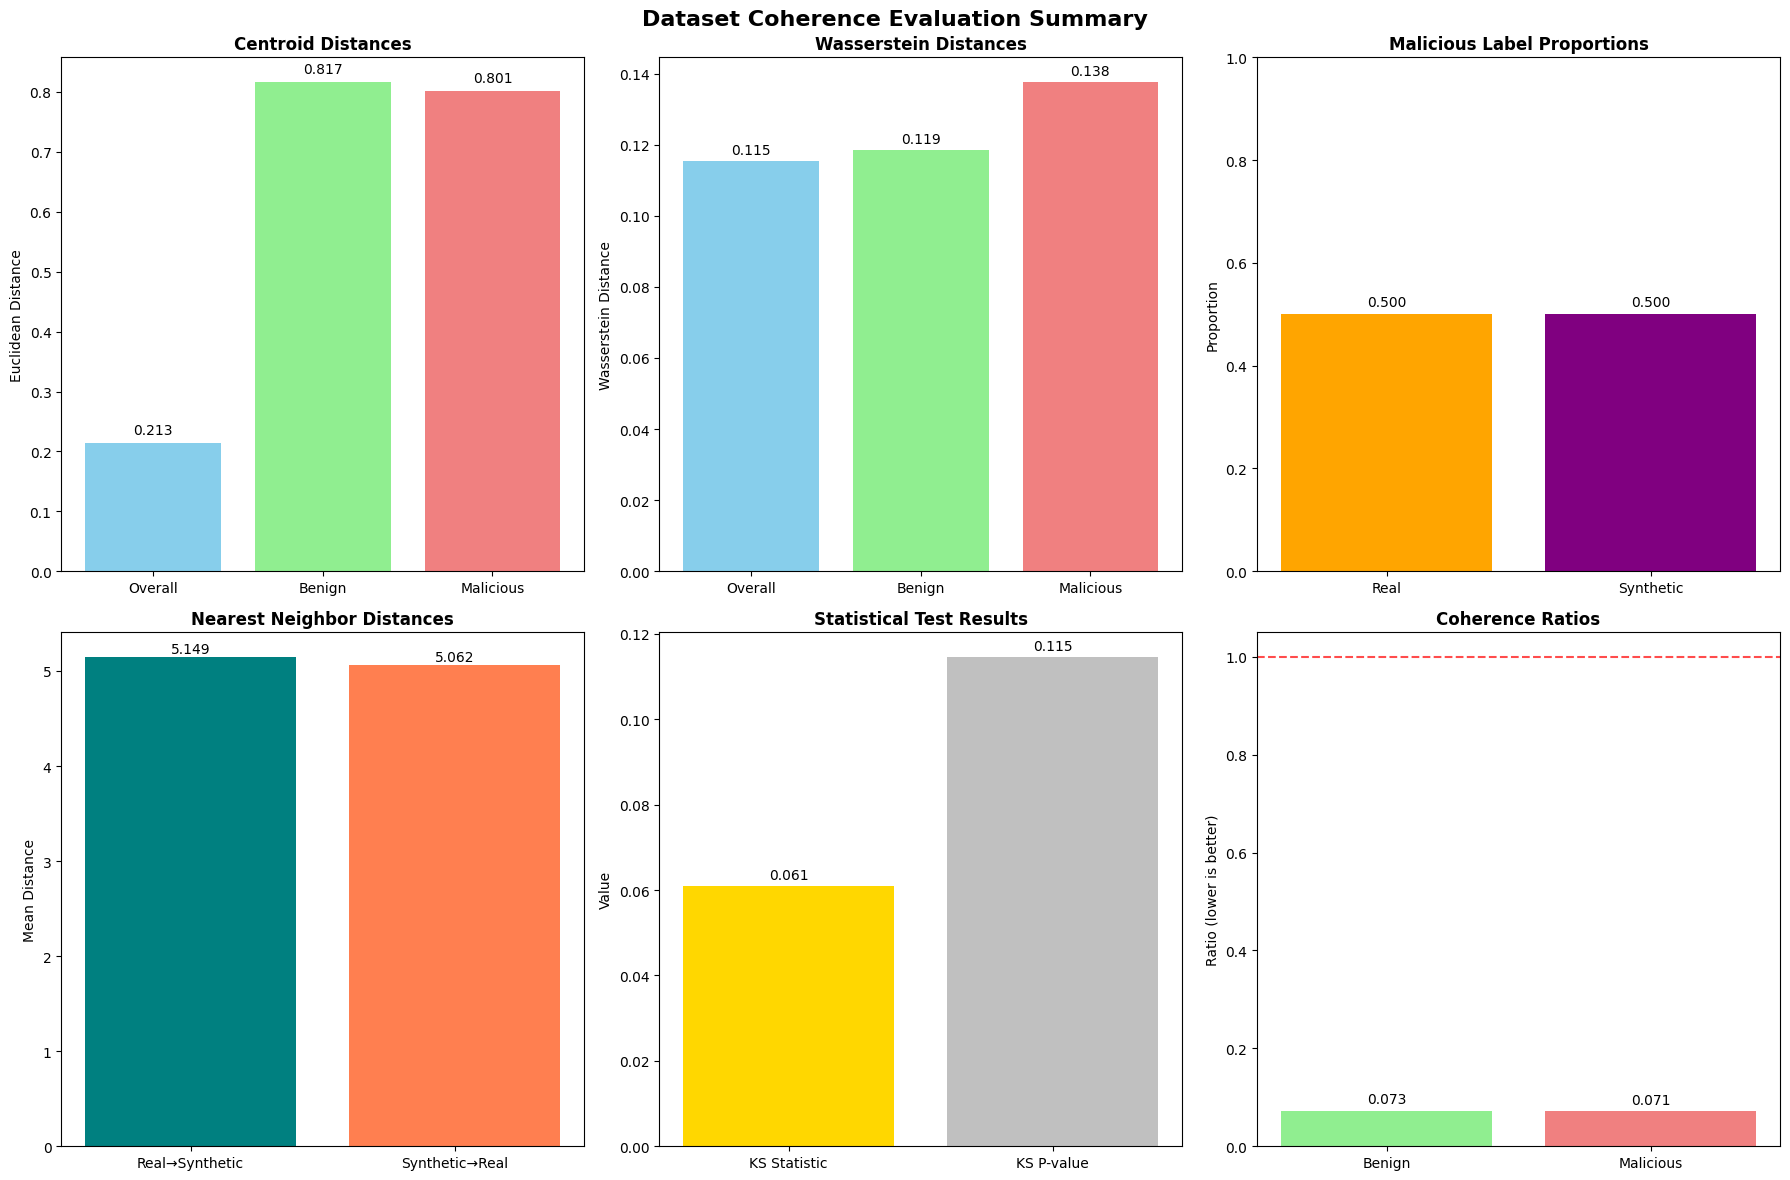


📋 COMPREHENSIVE EVALUATION REPORT
🎯 OVERALL QUALITY SCORE: 4/5 (80.0%)
✅ EXCELLENT: Synthetic data closely matches real data distribution

📊 DETAILED METRICS:
----------------------------------------
Centroid Distances:
  • Overall: 0.2135
  • Benign: 0.8168
  • Malicious: 0.8008

Label Distribution:
  • Real malicious: 50.00%
  • Synthetic malicious: 50.00%
  • Difference: 0.00%

Nearest Neighbor Analysis:
  • Real→Synthetic: 5.1487
  • Synthetic→Real: 5.0622

Statistical Tests:
  • KS statistic: 0.0609
  • KS p-value: 0.1146
  • Distributions similar: True

MMD Distance: 0.0475

🔍 INTERPRETATION:
----------------------------------------
• Lower centroid distances indicate better synthetic data quality
• Coherence ratios < 1.0 indicate good label separation preservation
• Higher KS p-values indicate more similar distributions
• Lower MMD values indicate better distribution matching
• Balanced label proportions indicate realistic data generation


In [9]:
results = evaluate_dataset_coherence(real_features, synthetic_features, real_labels, synthetic_labels)